# K-Means

In [74]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
import random

random.seed(42)

def load_data():
    X = np.load("data/ex7_X.npy")
    return X

def draw_line(p1, p2, style="-k", linewidth=1):
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], style, linewidth=linewidth)

def plot_data_points(X, idx):
    # plots data points in X, coloring them so that those with the same
    # index assignments in idx have the same color
    plt.scatter(X[:, 0], X[:, 1], c=idx)
    
def plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i):
    # Plot the examples
    plot_data_points(X, idx)
    
    # Plot the centroids as black 'x's
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', c='k', linewidths=3)
    
    # Plot history of the centroids with lines
    for j in range(centroids.shape[0]):
        draw_line(centroids[j, :], previous_centroids[j, :])
    
    plt.title("Iteration number %d" %i)

X = load_data()
print("First five elements of X are:\n", X[:5]) 
print('The shape of X is:', X.shape)

First five elements of X are:
 [[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]
The shape of X is: (300, 2)


In [75]:
def find_closest_centroids(X: NDArray, centroids: NDArray) -> NDArray:
    k = centroids.shape[0]
    m = X.shape[0]
    idx = np.zeros(m, dtype=int)

    for i in range(m):
        dist = []
        for j in range(k):
            norm_2 = np.sum((X[i] - centroids[j])**2)
            dist.append(norm_2)
        
        idx[i] = np.argmin(dist)
    return idx

initial_centroids = np.array([[3,3], [6,2], [8,5]])
idx = find_closest_centroids(X, initial_centroids)
print("First three elements in idx are:", idx[:3])

First three elements in idx are: [0 2 1]


In [76]:
def compute_centroids(X: NDArray, idx: NDArray, K: int) -> NDArray:
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        centroids[k] = np.mean(X[idx == k], axis=0)
    return centroids

K = 3
centroids = compute_centroids(X, idx, K)
print (f'The centroids shape: {centroids.shape}')
print("The centroids are:", centroids)

The centroids shape: (3, 2)
The centroids are: [[2.42830111 3.15792418]
 [5.81350331 2.63365645]
 [7.11938687 3.6166844 ]]


K-Means iteration    1/10
K-Means iteration    2/10
K-Means iteration    3/10
K-Means iteration    4/10
K-Means iteration    5/10
K-Means iteration    6/10
K-Means iteration    7/10
K-Means iteration    8/10
K-Means iteration    9/10
K-Means iteration   10/10


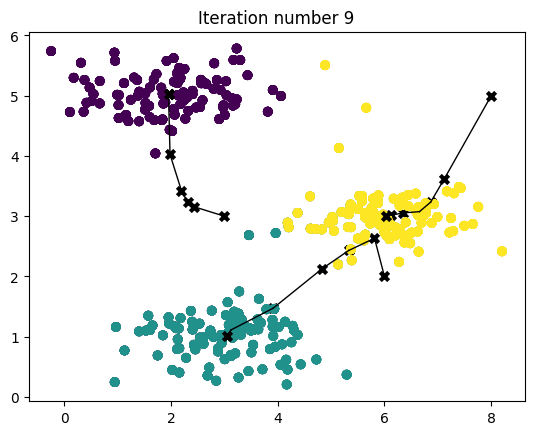

In [77]:
def run_kMeans(X, initial_centroids, max_iters=10, plot_progress=False):

    centroids = initial_centroids
    previous_centroids = centroids
    K = initial_centroids.shape[0]
    for i in range(max_iters):
        print(f"K-Means iteration {i+1:4d}/{max_iters}")
        idx = find_closest_centroids(X, centroids)

        if plot_progress:
            plot_progress_kMeans(X, centroids, previous_centroids, idx, K, i)
            previous_centroids = centroids

        centroids = compute_centroids(X, idx, K)
    
    plt.show() 
    return centroids, idx

initial_centroids = np.array([[3,3],[6,2],[8,5]])
K = 3
max_iters = 10
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)


K-Means iteration    1/10
K-Means iteration    2/10
K-Means iteration    3/10
K-Means iteration    4/10
K-Means iteration    5/10
K-Means iteration    6/10
K-Means iteration    7/10
K-Means iteration    8/10
K-Means iteration    9/10
K-Means iteration   10/10


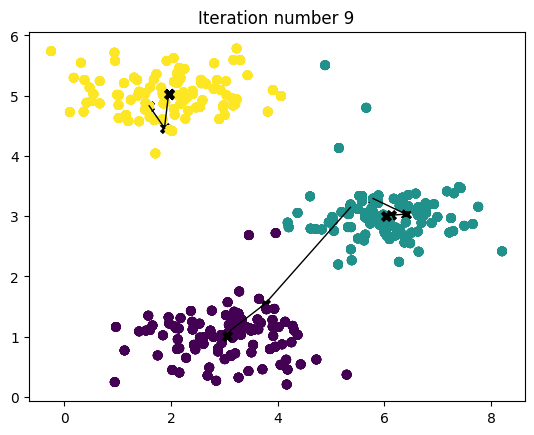

In [78]:
def kMeans_init_centroids(X, K) -> NDArray:
    idx = np.random.choice(X.shape[0], K, replace=False)
    return X[idx, :]

K = 3
max_iters = 10
initial_centroids = kMeans_init_centroids(X, K)
centroids, idx = run_kMeans(X, initial_centroids, max_iters, plot_progress=True)

## Compress Image

Shape of original_img is: (128, 128, 3)
first pixel
[0.85882354 0.7058824  0.40392157]


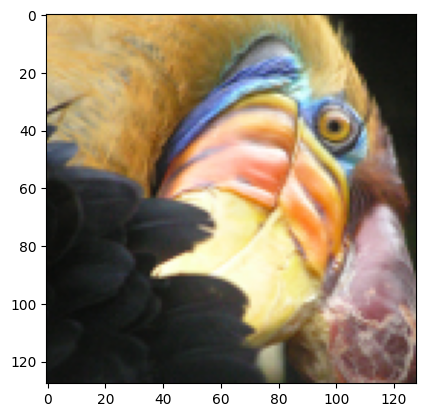

In [79]:
original_img = plt.imread('data/bird_small.png')
plt.imshow(original_img)
print("Shape of original_img is:", original_img.shape)
print(f'first pixel\n{original_img[0,0,:]}')

In [80]:
original_img = original_img
X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))
print(f'X_img shape: {X_img.shape}')

X_img shape: (16384, 3)


K-Means iteration    1/10
K-Means iteration    2/10
K-Means iteration    3/10
K-Means iteration    4/10
K-Means iteration    5/10
K-Means iteration    6/10
K-Means iteration    7/10
K-Means iteration    8/10
K-Means iteration    9/10
K-Means iteration   10/10


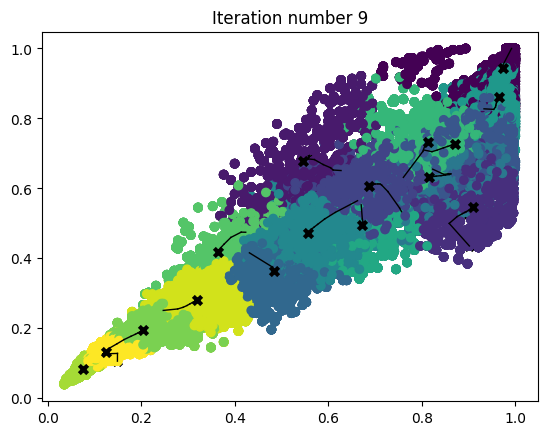

Shape of idx: (16384,)
Closest centroid for the random 10 elements: [10  0 15 15  5 12  0  7 12  7]


In [81]:
K = 16
iterations = 10
initial_centroids = kMeans_init_centroids(X_img, K)
centroids, idx = run_kMeans(X_img, initial_centroids, max_iters, plot_progress=True)
print("Shape of idx:", idx.shape)
idxs = np.random.choice(idx, 10)
print("Closest centroid for the random 10 elements:", idxs)

Centroids shape: (16, 3)
X_recovered shape: (16384, 3)
X_recovered shape/reshape: (128, 128, 3)


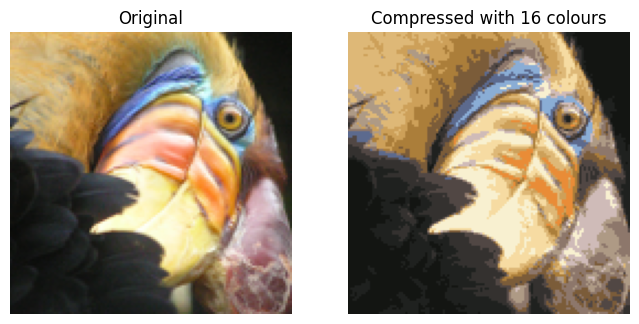

In [86]:
X_recovered = centroids[idx, :] 
print(f'Centroids shape: {centroids.shape}')
print(f'X_recovered shape: {X_recovered.shape}')

X_recovered = np.reshape(X_recovered, original_img.shape) 
print(f'X_recovered shape/reshape: {X_recovered.shape}')

fig, ax = plt.subplots(1,2, figsize=(8,8))
plt.axis('off')

ax[0].imshow(original_img)
ax[0].set_title('Original')
ax[0].set_axis_off()


# Display compressed image
ax[1].imshow((X_recovered))
ax[1].set_title('Compressed with %d colours'%K)
ax[1].set_axis_off()
